# Package Requirements

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Print versions of the packages being used
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("seaborn version:", sns.__version__)
print("matplotlib version:", matplotlib.__version__)

pandas version: 2.2.3
numpy version: 1.26.4
seaborn version: 0.13.2
matplotlib version: 3.9.2


# For the barplot in Figure 2 f,g,h

## Epithelial

                         pathway  active_tissues
0        Notch signaling pathway               1
1         MAPK signaling pathway               6
2          Ras signaling pathway               8
3         Rap1 signaling pathway               8
4     JAK-STAT signaling pathway               3
5   NF-kappa B signaling pathway               5
6          TNF signaling pathway               7
7        HIF-1 signaling pathway              14
8         FoxO signaling pathway               4
9      Calcium signaling pathway               6
10        cAMP signaling pathway               8
11    cGMP-PKG signaling pathway               8
12    PI3K-Akt signaling pathway              10


/tmp/ipykernel_3397073/2133678604.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


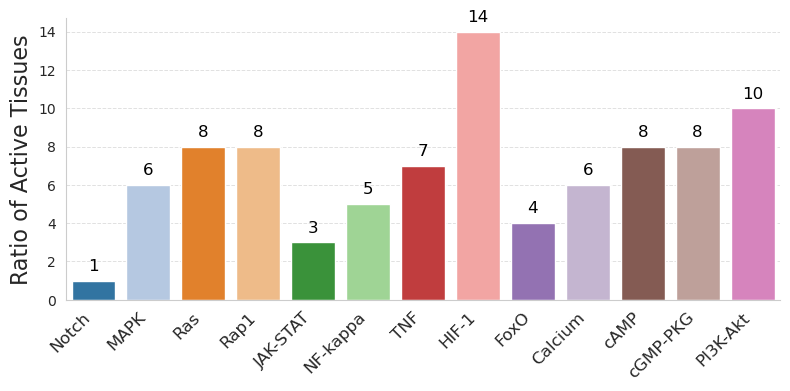

In [2]:
df = pd.read_csv('Results/Epithelial/combined_sorted_pathways_results.csv')
# Define the p-value cutoff
p_value_cutoff = 0.05

# Filter pathways with p_value < 0.05
active_df = df[df['p_value'] <= p_value_cutoff]

# Exclude pathways that start with 'chr' to focus on signaling pathways
signaling_active_df = active_df[~active_df['pathway'].str.startswith('chr')]

# Identify all signaling pathways (excluding chromosome regions)
all_signaling_pathways = df[~df['pathway'].str.startswith('chr')]['pathway'].unique()

# Group by 'pathway' and count unique 'tissue' entries
pathway_tissue_counts = signaling_active_df.groupby('pathway')['tissue'].nunique().reset_index()
pathway_tissue_counts.rename(columns={'tissue': 'active_tissues'}, inplace=True)

# Create a DataFrame with all signaling pathways
all_pathways_df = pd.DataFrame({'pathway': all_signaling_pathways})

# Merge with the active counts, filling NaN with 0
final_counts = all_pathways_df.merge(pathway_tissue_counts, on='pathway', how='left')
final_counts['active_tissues'] = final_counts['active_tissues'].fillna(0).astype(int)

# Display the final_counts DataFrame
print(final_counts)

# Shorten pathway names by extracting the first word before the first space
# You can adjust this logic based on your specific naming conventions
final_counts['short_pathway'] = final_counts['pathway'].apply(lambda x: x.split(' ')[0])

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Define the size of the plot
plt.figure(figsize=(8, 4))

# Define a 13-color palette using 'tab20'
color_palette = sns.color_palette("tab20", 13)

# Create the bar plot using the defined palette
sns.barplot(
    data=final_counts,
    x='short_pathway',
    y='active_tissues',
    palette=color_palette
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)

# Add labels and title with increased font sizes
plt.xlabel('')
plt.ylabel('Ratio of Active Tissues', fontsize=16)
# plt.title('Stromal Cells', fontsize=18)

# Remove the top and right spines
sns.despine(top=True, right=True)

# Customize the horizontal grid lines
ax = plt.gca()  # Get current Axes instance

ax.grid(
    axis='y',            # Apply changes to horizontal grid lines
    color='lightgrey',   # Change grid line color
    linestyle='--',      # Change grid line style to dashed
    linewidth=0.7,       # Adjust grid line thickness
    alpha=0.7            # Set transparency for grid lines
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # Convert to integer
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=12,
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )
        
# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

## Endothelial

                         pathway  active_tissues
0        Notch signaling pathway               3
1         MAPK signaling pathway              10
2          Ras signaling pathway              10
3         Rap1 signaling pathway              11
4     JAK-STAT signaling pathway               5
5   NF-kappa B signaling pathway               6
6          TNF signaling pathway              10
7        HIF-1 signaling pathway              10
8         FoxO signaling pathway               7
9      Calcium signaling pathway               9
10        cAMP signaling pathway               8
11    cGMP-PKG signaling pathway              10
12    PI3K-Akt signaling pathway              11


/tmp/ipykernel_3397073/1855010717.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


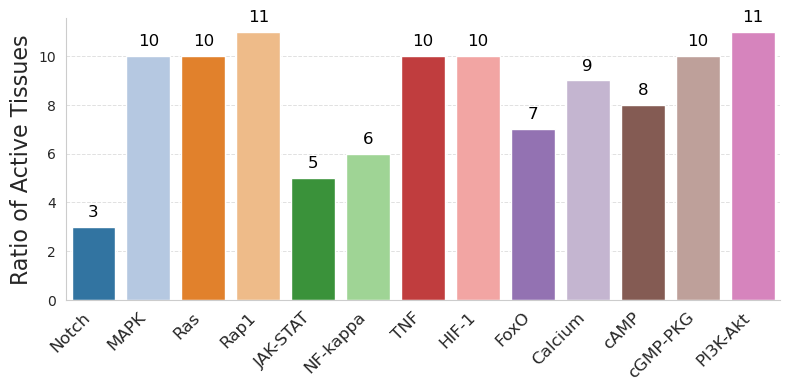

In [3]:
df = pd.read_csv('Results/Endothelial/combined_sorted_pathways_results.csv')
# Define the p-value cutoff
p_value_cutoff = 0.05

# Filter pathways with p_value < 0.05
active_df = df[df['p_value'] <= p_value_cutoff]

# Exclude pathways that start with 'chr' to focus on signaling pathways
signaling_active_df = active_df[~active_df['pathway'].str.startswith('chr')]

# Identify all signaling pathways (excluding chromosome regions)
all_signaling_pathways = df[~df['pathway'].str.startswith('chr')]['pathway'].unique()

# Group by 'pathway' and count unique 'tissue' entries
pathway_tissue_counts = signaling_active_df.groupby('pathway')['tissue'].nunique().reset_index()
pathway_tissue_counts.rename(columns={'tissue': 'active_tissues'}, inplace=True)

# Create a DataFrame with all signaling pathways
all_pathways_df = pd.DataFrame({'pathway': all_signaling_pathways})

# Merge with the active counts, filling NaN with 0
final_counts = all_pathways_df.merge(pathway_tissue_counts, on='pathway', how='left')
final_counts['active_tissues'] = final_counts['active_tissues'].fillna(0).astype(int)

# Display the final_counts DataFrame
print(final_counts)

# Shorten pathway names by extracting the first word before the first space
# You can adjust this logic based on your specific naming conventions
final_counts['short_pathway'] = final_counts['pathway'].apply(lambda x: x.split(' ')[0])

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Define the size of the plot
plt.figure(figsize=(8, 4))

# Define a 13-color palette using 'tab20'
color_palette = sns.color_palette("tab20", 13)

# Create the bar plot using the defined palette
sns.barplot(
    data=final_counts,
    x='short_pathway',
    y='active_tissues',
    palette=color_palette
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)

# Add labels and title with increased font sizes
plt.xlabel('')
plt.ylabel('Ratio of Active Tissues', fontsize=16)
# plt.title('Stromal Cells', fontsize=18)

# Remove the top and right spines
sns.despine(top=True, right=True)

# Customize the horizontal grid lines
ax = plt.gca()  # Get current Axes instance

ax.grid(
    axis='y',            # Apply changes to horizontal grid lines
    color='lightgrey',   # Change grid line color
    linestyle='--',      # Change grid line style to dashed
    linewidth=0.7,       # Adjust grid line thickness
    alpha=0.7            # Set transparency for grid lines
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # Convert to integer
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=12,
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )
        
# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

## Stromal

                         pathway  active_tissues
0        Notch signaling pathway               6
1         MAPK signaling pathway              12
2          Ras signaling pathway              14
3         Rap1 signaling pathway              14
4     JAK-STAT signaling pathway              14
5   NF-kappa B signaling pathway               9
6          TNF signaling pathway              15
7        HIF-1 signaling pathway              19
8         FoxO signaling pathway              14
9      Calcium signaling pathway              16
10        cAMP signaling pathway              16
11    cGMP-PKG signaling pathway              20
12    PI3K-Akt signaling pathway              20


/tmp/ipykernel_3397073/2304644082.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


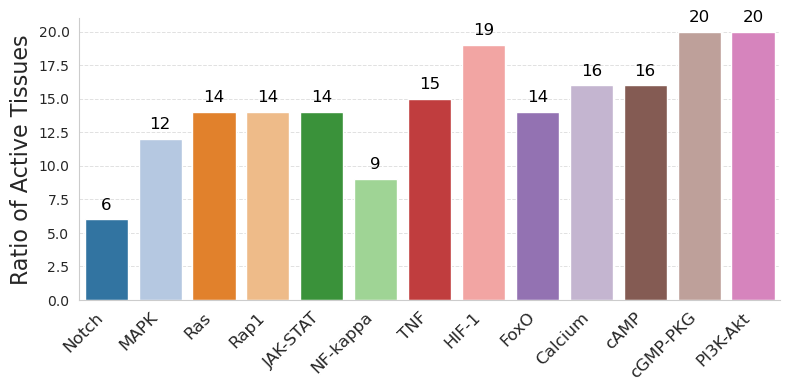

In [4]:
df = pd.read_csv('Results/Stromal/combined_sorted_pathways_results.csv')
# Define the p-value cutoff
p_value_cutoff = 0.05

# Filter pathways with p_value < 0.05
active_df = df[df['p_value'] <= p_value_cutoff]

# Exclude pathways that start with 'chr' to focus on signaling pathways
signaling_active_df = active_df[~active_df['pathway'].str.startswith('chr')]

# Identify all signaling pathways (excluding chromosome regions)
all_signaling_pathways = df[~df['pathway'].str.startswith('chr')]['pathway'].unique()

# Group by 'pathway' and count unique 'tissue' entries
pathway_tissue_counts = signaling_active_df.groupby('pathway')['tissue'].nunique().reset_index()
pathway_tissue_counts.rename(columns={'tissue': 'active_tissues'}, inplace=True)

# Create a DataFrame with all signaling pathways
all_pathways_df = pd.DataFrame({'pathway': all_signaling_pathways})

# Merge with the active counts, filling NaN with 0
final_counts = all_pathways_df.merge(pathway_tissue_counts, on='pathway', how='left')
final_counts['active_tissues'] = final_counts['active_tissues'].fillna(0).astype(int)

# Display the final_counts DataFrame
print(final_counts)

# Shorten pathway names by extracting the first word before the first space
# You can adjust this logic based on your specific naming conventions
final_counts['short_pathway'] = final_counts['pathway'].apply(lambda x: x.split(' ')[0])

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Define the size of the plot
plt.figure(figsize=(8, 4))

# Define a 13-color palette using 'tab20'
color_palette = sns.color_palette("tab20", 13)

# Create the bar plot using the defined palette
sns.barplot(
    data=final_counts,
    x='short_pathway',
    y='active_tissues',
    palette=color_palette
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)

# Add labels and title with increased font sizes
plt.xlabel('')
plt.ylabel('Ratio of Active Tissues', fontsize=16)
# plt.title('Stromal Cells', fontsize=18)

# Remove the top and right spines
sns.despine(top=True, right=True)

# Customize the horizontal grid lines
ax = plt.gca()  # Get current Axes instance

ax.grid(
    axis='y',            # Apply changes to horizontal grid lines
    color='lightgrey',   # Change grid line color
    linestyle='--',      # Change grid line style to dashed
    linewidth=0.7,       # Adjust grid line thickness
    alpha=0.7            # Set transparency for grid lines
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',  # Convert to integer
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=12,
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )
        
# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

# For the supp.human_atlas

## Stromal

Total unique tissues: 21


/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has

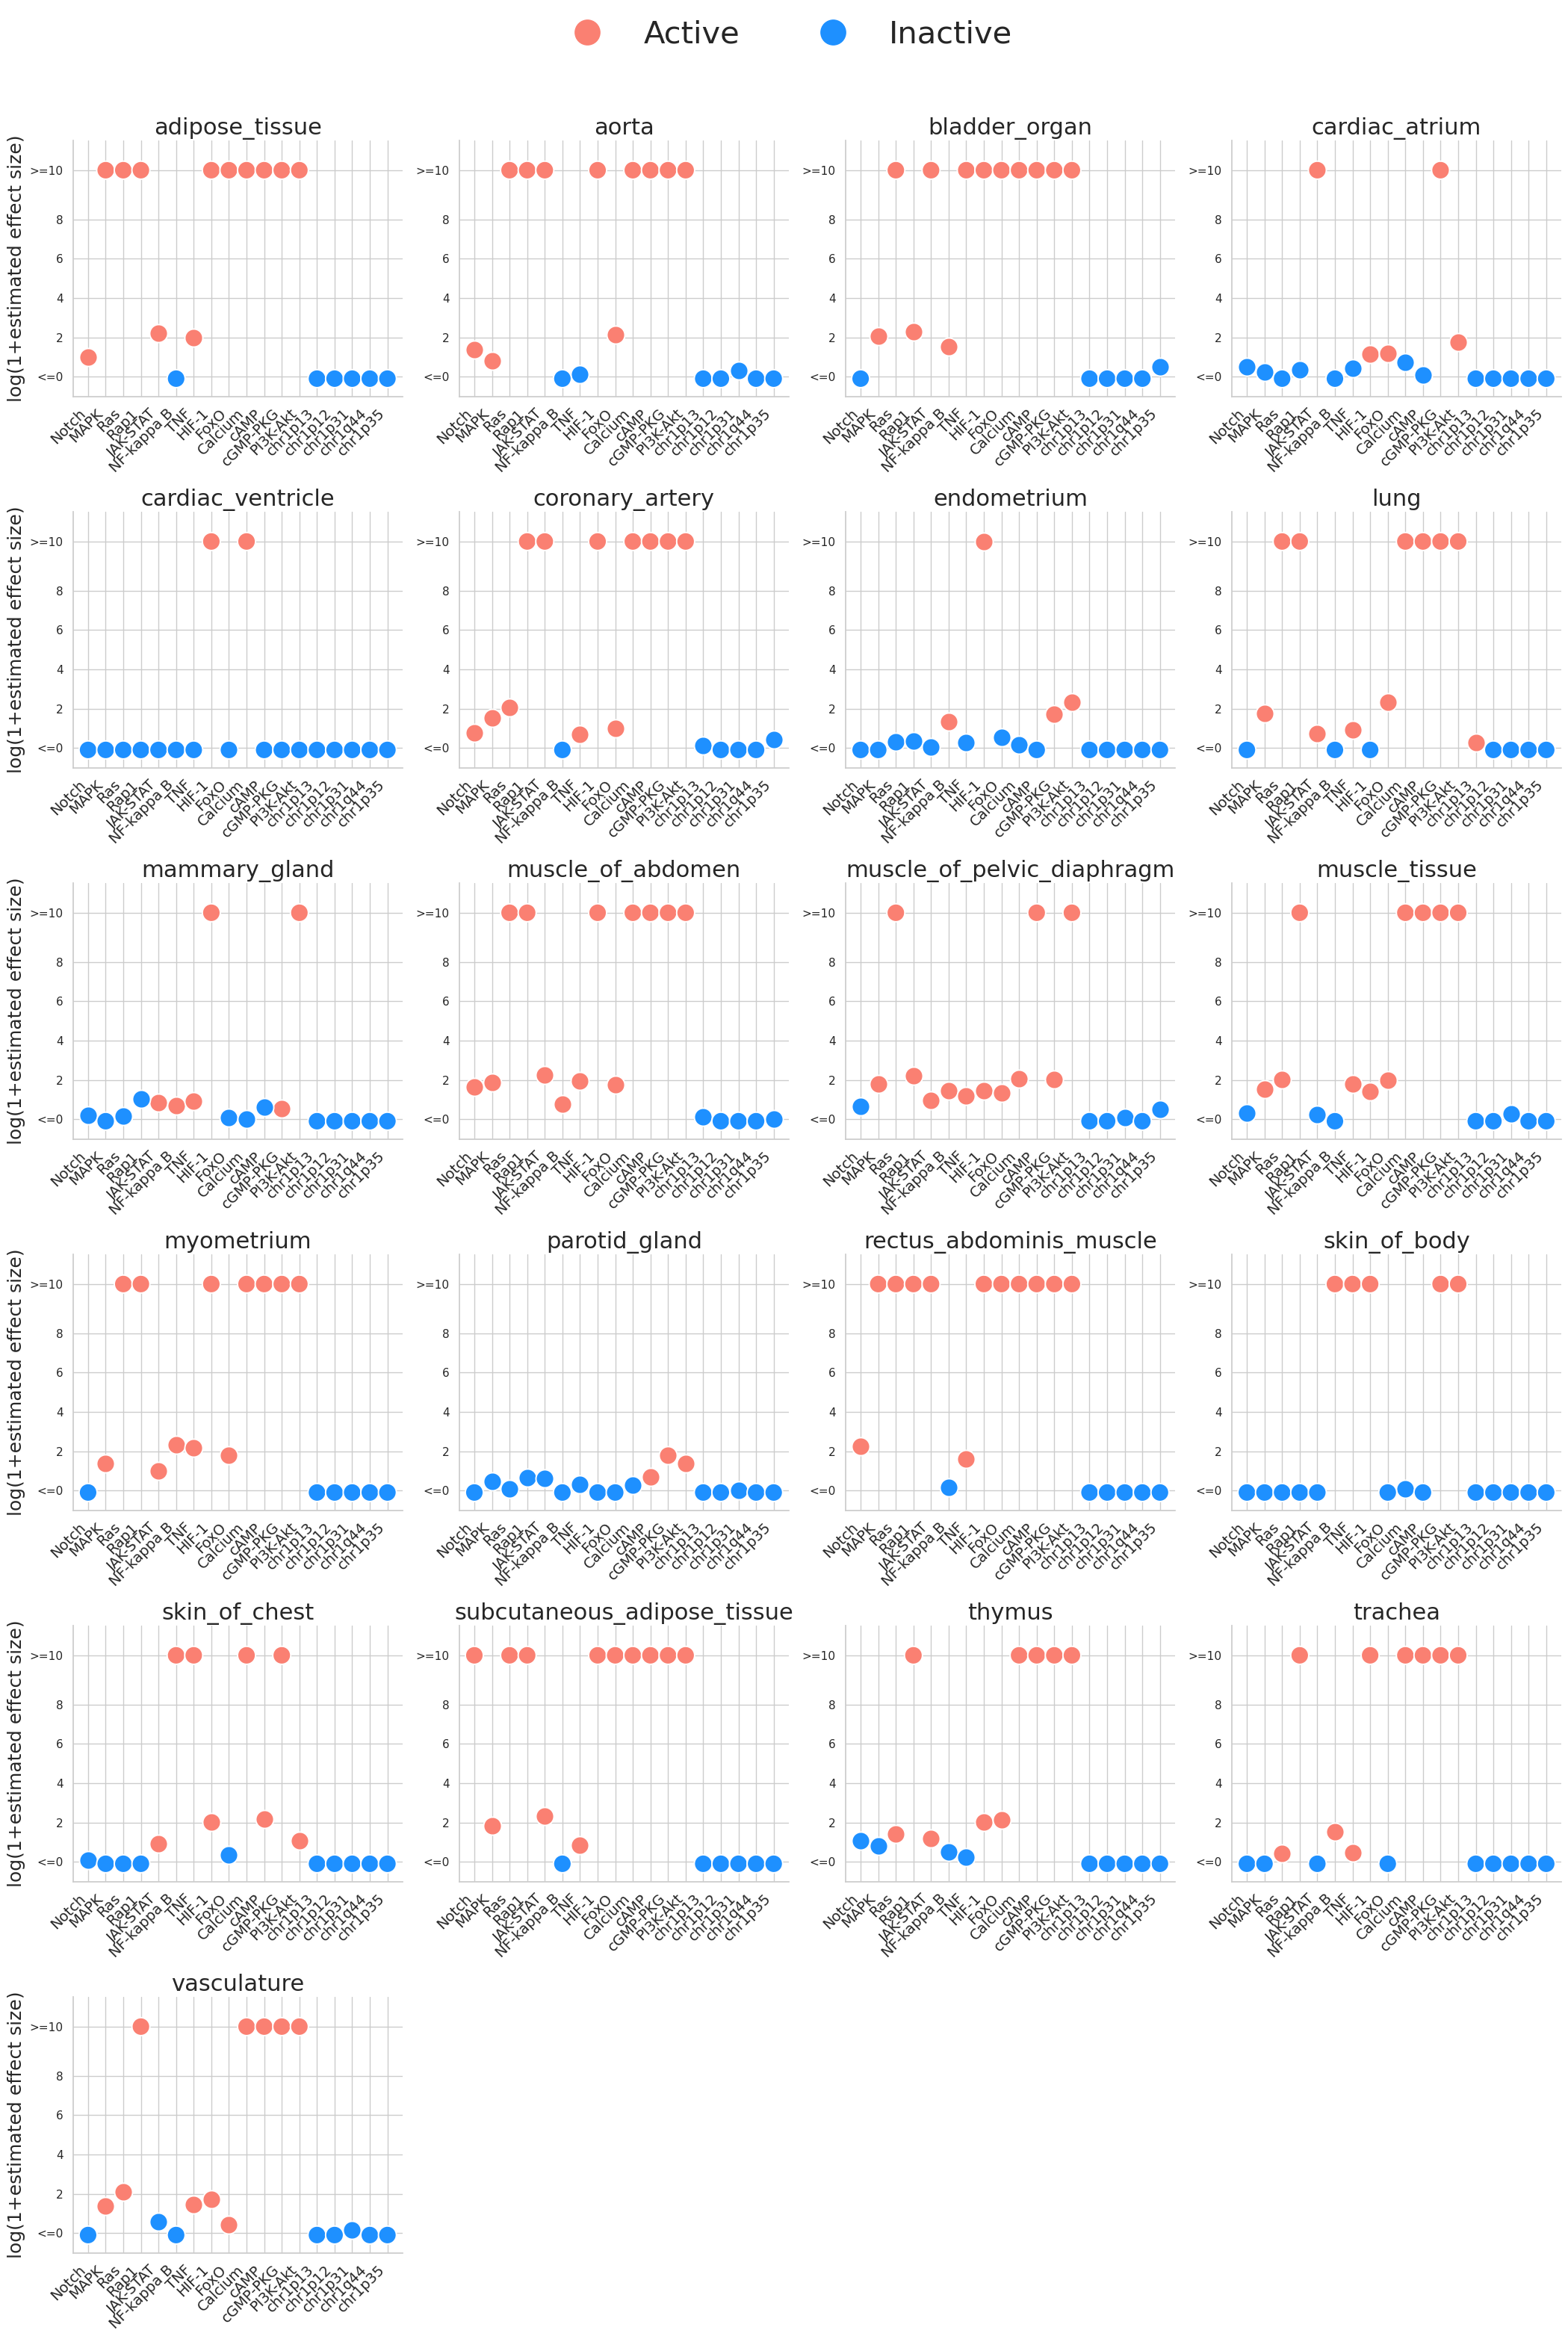

In [5]:
# ----------------------------
# 1. Data Preprocessing
# ----------------------------

# Load the dataset
df = pd.read_csv('Results/Stromal/combined_sorted_pathways_results.csv')

# Define the p-value cutoff
p_value_cutoff = 0.05

# Create 'status' column based on p-value
df['status'] = df['p_value'].apply(lambda x: 'Active' if x <= p_value_cutoff else 'Inactive')

# Shorten pathway names by removing 'signaling pathway' if present
df['pathway_short'] = df['pathway'].apply(
    lambda x: x.replace(' signaling pathway', '') if 'signaling pathway' in x.lower() else x
)

# Categorize z_scores based on the specified cutoffs
def categorize_z_score(z):
    if z <= 0:
        return '<=0'
    elif z >= 10:
        return '>=10'
    else:
        return 'Normal'

df['z_score_category'] = df['z_score'].apply(categorize_z_score)

# Adjust z_score_plot for plotting
df['z_score_plot'] = df['z_score']  # Initialize with original z_scores

# Cap z_score <=0 to 0
df.loc[df['z_score_category'] == '<=0', 'z_score_plot'] = 0

# Apply log(1 + z_score) for 0 < z_score <10
df.loc[df['z_score_category'] == 'Normal', 'z_score_plot'] = np.log1p(df['z_score'])

# Represent z_score >=10 at y=10.5 without capping
df.loc[df['z_score_category'] == '>=10', 'z_score_plot'] = 10.5

# Create subsets for plotting
df_normal = df[df['z_score_category'] == 'Normal'].copy()
df_low = df[df['z_score_category'] == '<=0'].copy()
df_high = df[df['z_score_category'] == '>=10'].copy()

# Ensure 'pathway_short' maintains the original order as per CSV
# Extract the order of pathways as they appear in the CSV
pathway_order = df['pathway_short'].drop_duplicates().tolist()

# Convert 'pathway_short' to categorical with the defined order
df_normal['pathway_short'] = pd.Categorical(df_normal['pathway_short'], categories=pathway_order, ordered=True)
df_low['pathway_short'] = pd.Categorical(df_low['pathway_short'], categories=pathway_order, ordered=True)
df_high['pathway_short'] = pd.Categorical(df_high['pathway_short'], categories=pathway_order, ordered=True)

# ----------------------------
# 2. Visualization
# ----------------------------

# Set the overall aesthetic of the plots
sns.set(style="whitegrid")

# Get all unique tissues
unique_tissues = df['tissue'].unique()
print(f"Total unique tissues: {len(unique_tissues)}")

# Define the order of tissues to maintain consistency
tissue_order = sorted(unique_tissues)  # or use the original order as needed

# Initialize the FacetGrid with all tissues, ensuring dropna=False to include empty facets
g = sns.FacetGrid(
    df_normal, 
    col='tissue', 
    col_wrap=4, 
    height=5, 
    sharex=False, 
    sharey=False, 
    hue='status',
    hue_order=['Active', 'Inactive'],
    palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
    dropna=False,  # Include facets even if there's no data
    col_order=tissue_order  # Ensure all tissues are included
)

# Map the scatter plot for normal z_scores onto the FacetGrid without specifying hue again
g.map_dataframe(
    sns.scatterplot,
    x='pathway_short',
    y='z_score_plot',
    s=300,                    # Marker size for better visibility
    edgecolor='w',
    palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
    marker='o'                # Uniform circle marker
)

# Iterate through each facet and its corresponding tissue to plot low and high z_scores
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    # Plot z_score <=0 if exists
    tissue_low = df_low[df_low['tissue'] == tissue]
    if not tissue_low.empty:
        sns.scatterplot(
            x='pathway_short',
            y=np.full(len(tissue_low), -0.1),  # Set y=-0.1 for z_score <=0
            data=tissue_low,
            hue='status',
            marker='o',               # Same circle marker
            edgecolor='w',
            palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
            ax=ax,
            legend=False,             # Avoid duplicate legends
            s=300
        )
    
    # Plot z_score >=10 if exists
    tissue_high = df_high[df_high['tissue'] == tissue]
    if not tissue_high.empty:
        sns.scatterplot(
            x='pathway_short',
            y=np.full(len(tissue_high), 10.5),  # Set y=10.5 for z_score >=10
            data=tissue_high,
            hue='status',
            marker='o',               # Same circle marker
            edgecolor='w',
            palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
            ax=ax,
            legend=False,             # Avoid duplicate legends
            s=300
        )

# Remove the default legends from each subplot to prevent duplication
g.add_legend(title='', bbox_to_anchor=(1.2, 1), loc='upper left', borderaxespad=0.)

# Extract the legend handles and labels from one of the axes
handles, labels = g.axes[0].get_legend_handles_labels()

# Remove the existing legend to prevent duplication
g._legend.remove()

# Create custom legend elements with dot shapes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active',
           markerfacecolor='salmon', markersize=26, markeredgecolor='w'),
    Line2D([0], [0], marker='o', color='w', label='Inactive',
           markerfacecolor='dodgerblue', markersize=26, markeredgecolor='w')
]

# Add a new legend to the figure at the upper center
g.fig.legend(handles=legend_elements, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05), fontsize=30)

# Rotate x-axis labels for better readability and set y-axis to linear scale
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)
    
    # Set y-axis to linear scale
    ax.set_yscale('linear')
    
    # Set y-axis limits to accommodate the capped points
    ax.set_ylim(bottom=-1, top=12)  # Slightly below -0.1 and above 10.5 for padding
    
    # Define custom y-ticks
    ticks = [0, 2, 4, 6, 8, 10.5]
    labels_ticks = ['<=0', '2', '4', '6', '8','>=10']
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels_ticks)

# Set y-axis label and remove x-axis label
g.set_axis_labels("", "log(1+estimated effect size)", fontsize=18)

# Set facet titles to only show tissue names
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    ax.set_title(tissue, fontsize=22)

# Tight layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

## Epithelial

Total unique tissues: 18


/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has

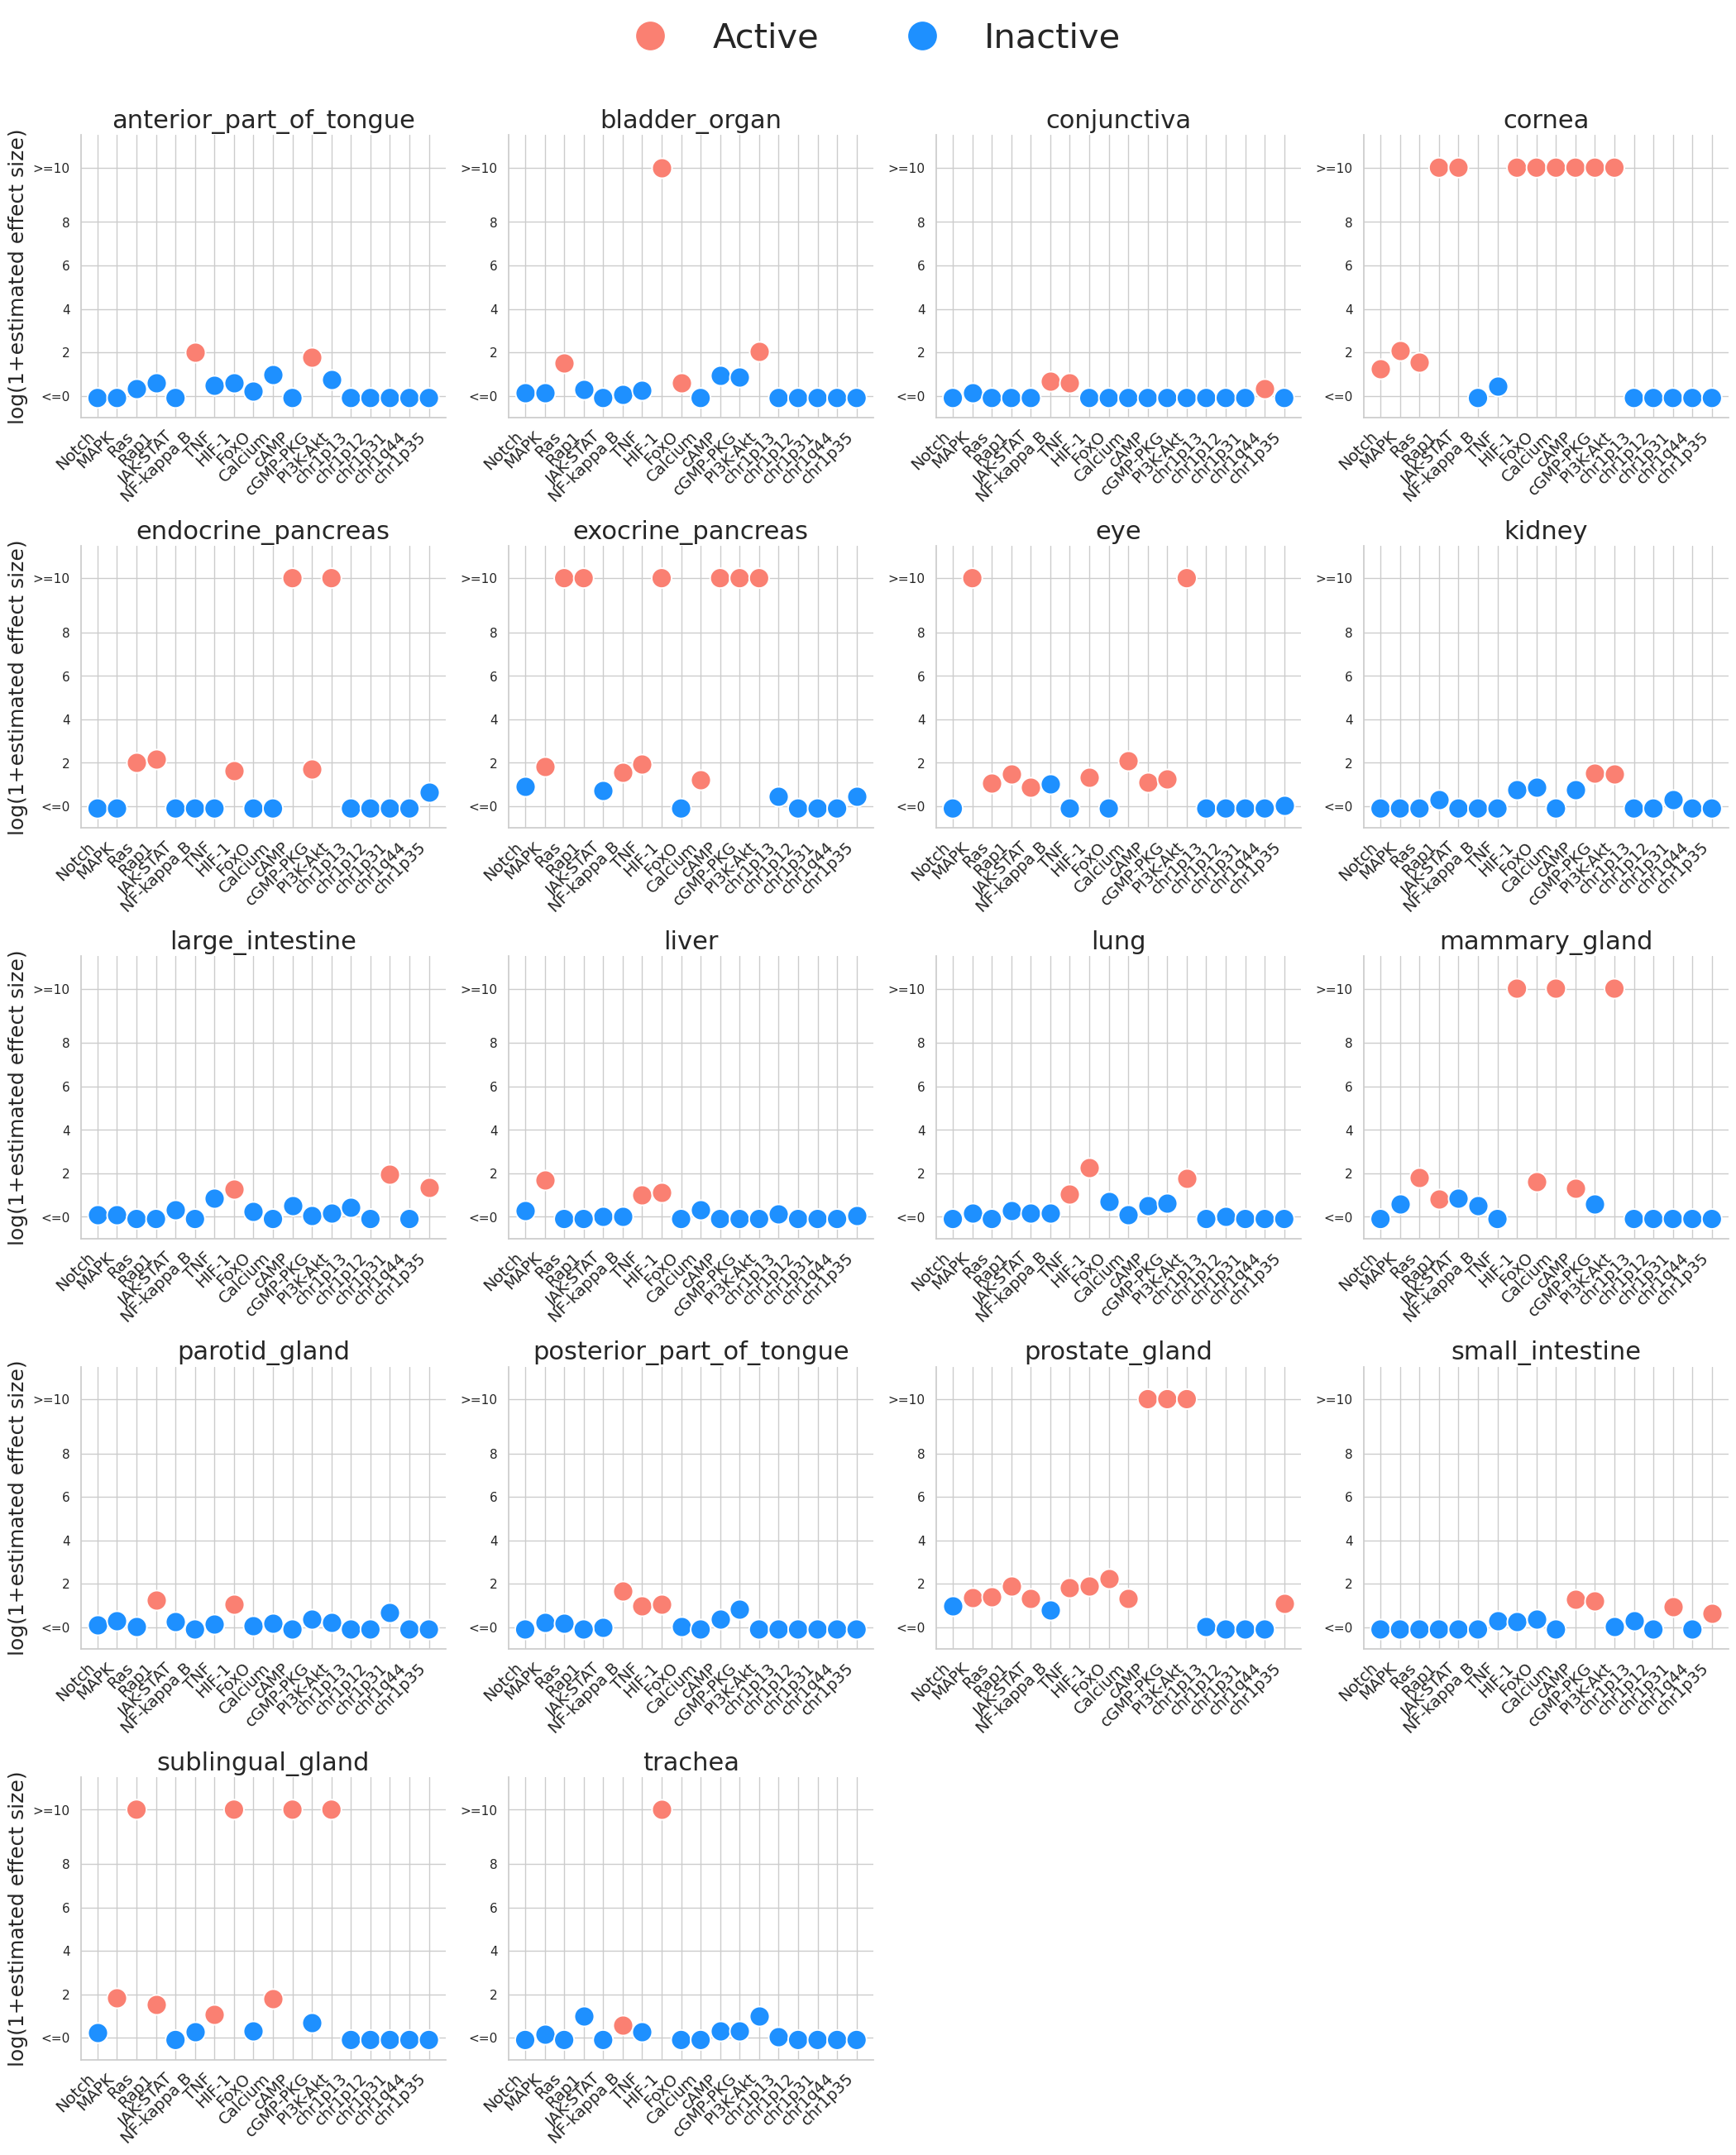

In [6]:
# ----------------------------
# 1. Data Preprocessing
# ----------------------------

# Load the dataset
df = pd.read_csv('Results/Epithelial/combined_sorted_pathways_results.csv')

# Define the p-value cutoff
p_value_cutoff = 0.05

# Create 'status' column based on p-value
df['status'] = df['p_value'].apply(lambda x: 'Active' if x <= p_value_cutoff else 'Inactive')

# Shorten pathway names by removing 'signaling pathway' if present
df['pathway_short'] = df['pathway'].apply(
    lambda x: x.replace(' signaling pathway', '') if 'signaling pathway' in x.lower() else x
)

# Categorize z_scores based on the specified cutoffs
def categorize_z_score(z):
    if z <= 0:
        return '<=0'
    elif z >= 10:
        return '>=10'
    else:
        return 'Normal'

df['z_score_category'] = df['z_score'].apply(categorize_z_score)

# Adjust z_score_plot for plotting
df['z_score_plot'] = df['z_score']  # Initialize with original z_scores

# Cap z_score <=0 to 0
df.loc[df['z_score_category'] == '<=0', 'z_score_plot'] = 0

# Apply log(1 + z_score) for 0 < z_score <10
df.loc[df['z_score_category'] == 'Normal', 'z_score_plot'] = np.log1p(df['z_score'])

# Represent z_score >=10 at y=10.5 without capping
df.loc[df['z_score_category'] == '>=10', 'z_score_plot'] = 10.5

# Create subsets for plotting
df_normal = df[df['z_score_category'] == 'Normal'].copy()
df_low = df[df['z_score_category'] == '<=0'].copy()
df_high = df[df['z_score_category'] == '>=10'].copy()

# Ensure 'pathway_short' maintains the original order as per CSV
# Extract the order of pathways as they appear in the CSV
pathway_order = df['pathway_short'].drop_duplicates().tolist()

# Convert 'pathway_short' to categorical with the defined order
df_normal['pathway_short'] = pd.Categorical(df_normal['pathway_short'], categories=pathway_order, ordered=True)
df_low['pathway_short'] = pd.Categorical(df_low['pathway_short'], categories=pathway_order, ordered=True)
df_high['pathway_short'] = pd.Categorical(df_high['pathway_short'], categories=pathway_order, ordered=True)

# ----------------------------
# 2. Visualization
# ----------------------------

# Set the overall aesthetic of the plots
sns.set(style="whitegrid")

# Get all unique tissues
unique_tissues = df['tissue'].unique()
print(f"Total unique tissues: {len(unique_tissues)}")

# Define the order of tissues to maintain consistency
tissue_order = sorted(unique_tissues)  # or use the original order as needed

# Initialize the FacetGrid with all tissues, ensuring dropna=False to include empty facets
g = sns.FacetGrid(
    df_normal, 
    col='tissue', 
    col_wrap=4, 
    height=5, 
    sharex=False, 
    sharey=False, 
    hue='status',
    hue_order=['Active', 'Inactive'],
    palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
    dropna=False,  # Include facets even if there's no data
    col_order=tissue_order  # Ensure all tissues are included
)

# Map the scatter plot for normal z_scores onto the FacetGrid without specifying hue again
g.map_dataframe(
    sns.scatterplot,
    x='pathway_short',
    y='z_score_plot',
    s=300,                    # Marker size for better visibility
    edgecolor='w',
    palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
    marker='o'                # Uniform circle marker
)

# Iterate through each facet and its corresponding tissue to plot low and high z_scores
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    # Plot z_score <=0 if exists
    tissue_low = df_low[df_low['tissue'] == tissue]
    if not tissue_low.empty:
        sns.scatterplot(
            x='pathway_short',
            y=np.full(len(tissue_low), -0.1),  # Set y=-0.1 for z_score <=0
            data=tissue_low,
            hue='status',
            marker='o',               # Same circle marker
            edgecolor='w',
            palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
            ax=ax,
            legend=False,             # Avoid duplicate legends
            s=300
        )
    
    # Plot z_score >=10 if exists
    tissue_high = df_high[df_high['tissue'] == tissue]
    if not tissue_high.empty:
        sns.scatterplot(
            x='pathway_short',
            y=np.full(len(tissue_high), 10.5),  # Set y=10.5 for z_score >=10
            data=tissue_high,
            hue='status',
            marker='o',               # Same circle marker
            edgecolor='w',
            palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
            ax=ax,
            legend=False,             # Avoid duplicate legends
            s=300
        )

# Remove the default legends from each subplot to prevent duplication
g.add_legend(title='', bbox_to_anchor=(1.2, 1), loc='upper left', borderaxespad=0.)

# Extract the legend handles and labels from one of the axes
handles, labels = g.axes[0].get_legend_handles_labels()

# Remove the existing legend to prevent duplication
g._legend.remove()

# Create custom legend elements with dot shapes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active',
           markerfacecolor='salmon', markersize=26, markeredgecolor='w'),
    Line2D([0], [0], marker='o', color='w', label='Inactive',
           markerfacecolor='dodgerblue', markersize=26, markeredgecolor='w')
]

# Add a new legend to the figure at the upper center
g.fig.legend(handles=legend_elements, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05), fontsize=30)

# Rotate x-axis labels for better readability and set y-axis to linear scale
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)
    
    # Set y-axis to linear scale
    ax.set_yscale('linear')
    
    # Set y-axis limits to accommodate the capped points
    ax.set_ylim(bottom=-1, top=12)  # Slightly below -0.1 and above 10.5 for padding
    
    # Define custom y-ticks
    ticks = [0, 2, 4, 6, 8, 10.5]
    labels_ticks = ['<=0', '2', '4', '6', '8','>=10']
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels_ticks)

# Set y-axis label and remove x-axis label
g.set_axis_labels("", "log(1+estimated effect size)", fontsize=18)

# Set facet titles to only show tissue names
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    ax.set_title(tissue, fontsize=22)

# Tight layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

## Endothelial

Total unique tissues: 11


/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/hpc/group/xielab/yx275/miniconda3/envs/star/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has

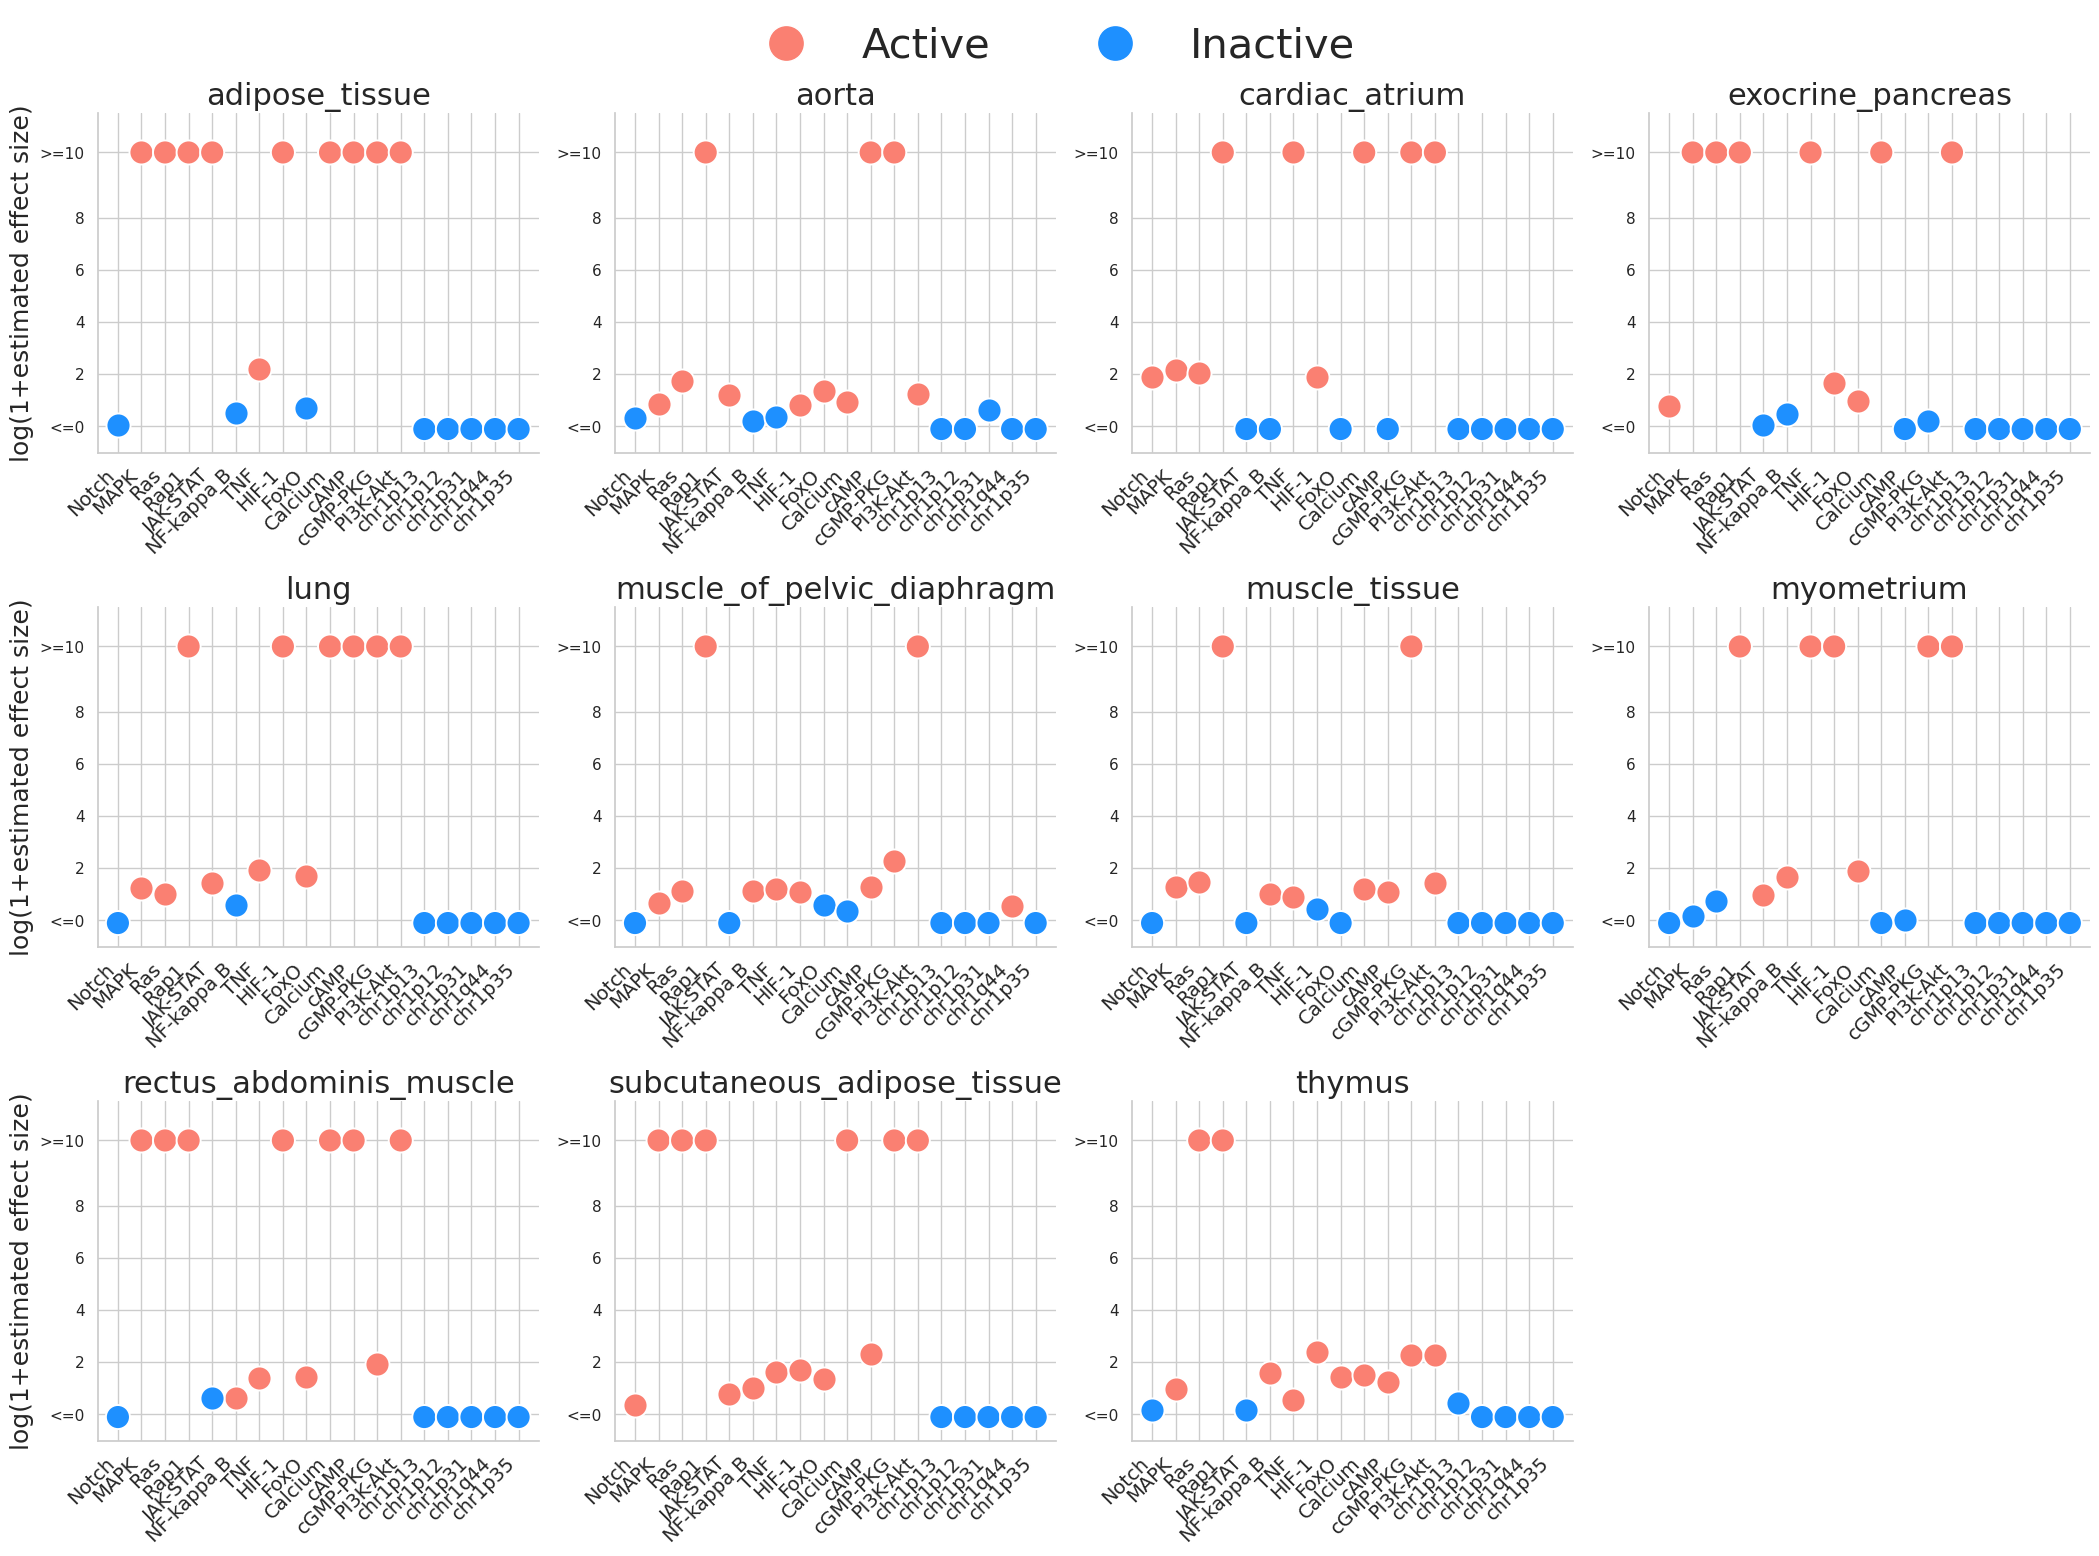

In [7]:
# ----------------------------
# 1. Data Preprocessing
# ----------------------------

# Load the dataset
df = pd.read_csv('Results/Endothelial/combined_sorted_pathways_results.csv')

# Define the p-value cutoff
p_value_cutoff = 0.05

# Create 'status' column based on p-value
df['status'] = df['p_value'].apply(lambda x: 'Active' if x <= p_value_cutoff else 'Inactive')

# Shorten pathway names by removing 'signaling pathway' if present
df['pathway_short'] = df['pathway'].apply(
    lambda x: x.replace(' signaling pathway', '') if 'signaling pathway' in x.lower() else x
)

# Categorize z_scores based on the specified cutoffs
def categorize_z_score(z):
    if z <= 0:
        return '<=0'
    elif z >= 10:
        return '>=10'
    else:
        return 'Normal'

df['z_score_category'] = df['z_score'].apply(categorize_z_score)

# Adjust z_score_plot for plotting
df['z_score_plot'] = df['z_score']  # Initialize with original z_scores

# Cap z_score <=0 to 0
df.loc[df['z_score_category'] == '<=0', 'z_score_plot'] = 0

# Apply log(1 + z_score) for 0 < z_score <10
df.loc[df['z_score_category'] == 'Normal', 'z_score_plot'] = np.log1p(df['z_score'])

# Represent z_score >=10 at y=10.5 without capping
df.loc[df['z_score_category'] == '>=10', 'z_score_plot'] = 10.5

# Create subsets for plotting
df_normal = df[df['z_score_category'] == 'Normal'].copy()
df_low = df[df['z_score_category'] == '<=0'].copy()
df_high = df[df['z_score_category'] == '>=10'].copy()

# Ensure 'pathway_short' maintains the original order as per CSV
# Extract the order of pathways as they appear in the CSV
pathway_order = df['pathway_short'].drop_duplicates().tolist()

# Convert 'pathway_short' to categorical with the defined order
df_normal['pathway_short'] = pd.Categorical(df_normal['pathway_short'], categories=pathway_order, ordered=True)
df_low['pathway_short'] = pd.Categorical(df_low['pathway_short'], categories=pathway_order, ordered=True)
df_high['pathway_short'] = pd.Categorical(df_high['pathway_short'], categories=pathway_order, ordered=True)

# ----------------------------
# 2. Visualization
# ----------------------------

# Set the overall aesthetic of the plots
sns.set(style="whitegrid")

# Get all unique tissues
unique_tissues = df['tissue'].unique()
print(f"Total unique tissues: {len(unique_tissues)}")

# Define the order of tissues to maintain consistency
tissue_order = sorted(unique_tissues)  # or use the original order as needed

# Initialize the FacetGrid with all tissues, ensuring dropna=False to include empty facets
g = sns.FacetGrid(
    df_normal, 
    col='tissue', 
    col_wrap=4, 
    height=5, 
    sharex=False, 
    sharey=False, 
    hue='status',
    hue_order=['Active', 'Inactive'],
    palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
    dropna=False,  # Include facets even if there's no data
    col_order=tissue_order  # Ensure all tissues are included
)

# Map the scatter plot for normal z_scores onto the FacetGrid without specifying hue again
g.map_dataframe(
    sns.scatterplot,
    x='pathway_short',
    y='z_score_plot',
    s=300,                    # Marker size for better visibility
    edgecolor='w',
    palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
    marker='o'                # Uniform circle marker
)

# Iterate through each facet and its corresponding tissue to plot low and high z_scores
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    # Plot z_score <=0 if exists
    tissue_low = df_low[df_low['tissue'] == tissue]
    if not tissue_low.empty:
        sns.scatterplot(
            x='pathway_short',
            y=np.full(len(tissue_low), -0.1),  # Set y=-0.1 for z_score <=0
            data=tissue_low,
            hue='status',
            marker='o',               # Same circle marker
            edgecolor='w',
            palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
            ax=ax,
            legend=False,             # Avoid duplicate legends
            s=300
        )
    
    # Plot z_score >=10 if exists
    tissue_high = df_high[df_high['tissue'] == tissue]
    if not tissue_high.empty:
        sns.scatterplot(
            x='pathway_short',
            y=np.full(len(tissue_high), 10.5),  # Set y=10.5 for z_score >=10
            data=tissue_high,
            hue='status',
            marker='o',               # Same circle marker
            edgecolor='w',
            palette={'Active': 'salmon', 'Inactive': 'dodgerblue'},
            ax=ax,
            legend=False,             # Avoid duplicate legends
            s=300
        )

# Remove the default legends from each subplot to prevent duplication
g.add_legend(title='', bbox_to_anchor=(1.2, 1), loc='upper left', borderaxespad=0.)

# Extract the legend handles and labels from one of the axes
handles, labels = g.axes[0].get_legend_handles_labels()

# Remove the existing legend to prevent duplication
g._legend.remove()

# Create custom legend elements with dot shapes
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active',
           markerfacecolor='salmon', markersize=26, markeredgecolor='w'),
    Line2D([0], [0], marker='o', color='w', label='Inactive',
           markerfacecolor='dodgerblue', markersize=26, markeredgecolor='w')
]

# Add a new legend to the figure at the upper center
g.fig.legend(handles=legend_elements, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05), fontsize=30)

# Rotate x-axis labels for better readability and set y-axis to linear scale
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)
    
    # Set y-axis to linear scale
    ax.set_yscale('linear')
    
    # Set y-axis limits to accommodate the capped points
    ax.set_ylim(bottom=-1, top=12)  # Slightly below -0.1 and above 10.5 for padding
    
    # Define custom y-ticks
    ticks = [0, 2, 4, 6, 8, 10.5]
    labels_ticks = ['<=0', '2', '4', '6', '8','>=10']
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels_ticks)

# Set y-axis label and remove x-axis label
g.set_axis_labels("", "log(1+estimated effect size)", fontsize=18)

# Set facet titles to only show tissue names
for ax, tissue in zip(g.axes.flatten(), g.col_names):
    ax.set_title(tissue, fontsize=22)

# Tight layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

# The heatmap

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk", font_scale=1.3)  # try font_scale=2.0 if you want even bigger
sns.set_style("white")

def clean_pathway_name(name):
    return name.replace("pathway", "").strip()

# Define the p-value cutoff
p_value_cutoff = 0.05

# Define file paths for the three cell types.
# Adjust these paths as necessary for your setup.
cell_types = {
    'Epithelial': 'Results/Epithelial/combined_sorted_pathways_results.csv',
    'Stromal': 'Results/Stromal/combined_sorted_pathways_results.csv',
    'Endothelial': 'Results/Endothelial/combined_sorted_pathways_results.csv'
}

# Dictionary to hold the computed percentages for each cell type
cell_type_percentages = {}

for cell_type, file_path in cell_types.items():
    # Load the CSV for the cell type
    df = pd.read_csv(file_path)
    
    # Calculate the total number of unique tissues for this cell type
    total_tissues = df['tissue'].nunique()
    print(f"{cell_type}: Total number of unique tissues: {total_tissues}")
    
    # Filter for active pathways (p_value <= cutoff)
    active_df = df[df['p_value'] <= p_value_cutoff]
    
    # Exclude pathways that start with 'chr' (to focus on signaling pathways)
    active_df = active_df[~active_df['pathway'].str.startswith('chr')]
    
    # Get all signaling pathways in the dataset (removing those starting with 'chr')

    df['pathway'] = df['pathway'].apply(clean_pathway_name)  # Clean pathway names
    all_signaling_pathways = df[~df['pathway'].str.startswith('chr')]['pathway'].unique()
    
    # Group by pathway and count unique tissues where the pathway was active
    active_df['pathway'] = active_df['pathway'].apply(clean_pathway_name)  # Clean names in active_df
    pathway_tissue_counts = active_df.groupby('pathway')['tissue'].nunique().reset_index()
    pathway_tissue_counts.rename(columns={'tissue': 'active_tissues'}, inplace=True)
    
    # Create a DataFrame that has all signaling pathways
    all_pathways_df = pd.DataFrame({'pathway': all_signaling_pathways})
    
    # Merge the counts with the list of all pathways, filling missing counts with 0
    final_counts = all_pathways_df.merge(pathway_tissue_counts, on='pathway', how='left')
    final_counts['active_tissues'] = final_counts['active_tissues'].fillna(0).astype(int)
    
    # Calculate the percentage of active tissues per pathway
    final_counts['percent_active_tissues'] = (final_counts['active_tissues'] / total_tissues) * 100
    
    # Keep just the pathway and its percentage (and set pathway as index)
    pct_df = final_counts[['pathway', 'percent_active_tissues']].set_index('pathway')
    
    # Store the result in our dictionary
    cell_type_percentages[cell_type] = pct_df

# Combine the data from all cell types into one DataFrame.
# Rows are pathways; columns are cell types.
combined_df = pd.DataFrame()

for cell_type, pct_df in cell_type_percentages.items():
    combined_df[cell_type] = pct_df['percent_active_tissues']

# In case some pathways are missing for one or more cell types, fill with 0.
combined_df = combined_df.fillna(0)

# (Optional) Sort the pathways by the average percentage across cell types.
combined_df['mean'] = combined_df.mean(axis=1)
combined_df = combined_df.sort_values('mean', ascending=False)
combined_df = combined_df.drop(columns='mean')


# Create the heatmap
plt.figure(figsize=(10, max(6, len(combined_df) * 0.4)))  # Adjust figure height based on number of pathways
ax = sns.heatmap(
    combined_df,
    cmap="RdBu",    # You can choose a different color palette if desired
    cbar_kws={'label': 'Active Tissue Percentage'}
)

plt.ylabel(" ")
plt.tight_layout()

# Save and display the heatmap
# plt.savefig('active_tissue_heatmap.jpeg', dpi=600, bbox_inches='tight')
plt.show()